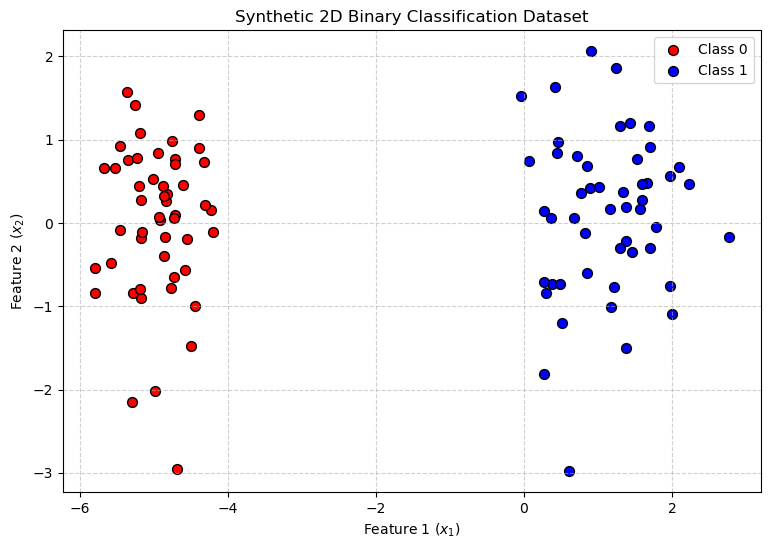

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30,
)
plt.figure(figsize=(9, 6))
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    edgecolors="k",
    s=50,
    label="Class 0",
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="blue",
    edgecolors="k",
    s=50,
    label="Class 1",
)

plt.xlabel("Feature 1 ($x_1$)")
plt.ylabel("Feature 2 ($x_2$)")
plt.title("Synthetic 2D Binary Classification Dataset")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

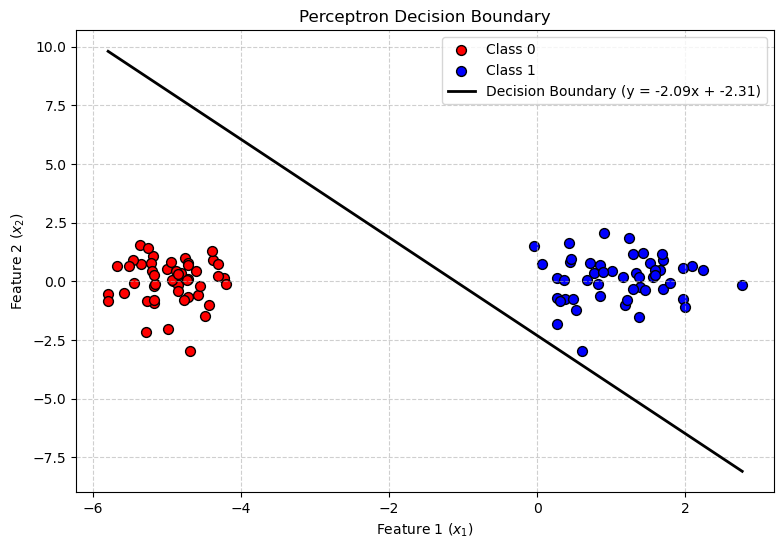

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

# 1. Generate Dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30,
)


# 2. Perceptron Implementation from Scratch
def perceptron(X, y, epochs=1000, lr=0.1):
    # Prepend dummy feature x0 = 1 for bias: shape becomes (n_samples, 3)
    X_bias = np.insert(X, 0, 1, axis=1)

    # Initialize weights: [w0, w1, w2]
    weights = np.ones(X_bias.shape[1])

    # Activation step function: 1 if z >= 0 else 0
    step = lambda z: 1 if z >= 0 else 0

    for epoch in range(epochs):
        # Pick a random sample (Stochastic Gradient / Perceptron update)
        idx = np.random.randint(0, X.shape[0])
        x_i = X_bias[idx]
        y_i = y[idx]

        # Compute prediction y_hat
        z = np.dot(weights, x_i)
        y_hat = step(z)

        # Weight update rule: w = w + lr * (y - y_hat) * x
        weights = weights + lr * (y_i - y_hat) * x_i

    return weights


# 3. Train the Perceptron
weights = perceptron(X, y, epochs=1000, lr=0.1)
w0, w1, w2 = weights

# 4. Extract Decision Boundary: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w1/w2)*x1 - (w0/w2)
m = -(w1 / w2)
c = -(w0 / w2)

x_line = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)
y_line = m * x_line + c

# 5. Visualize Decision Boundary
plt.figure(figsize=(9, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    edgecolors="k",
    s=50,
    label="Class 0",
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="blue",
    edgecolors="k",
    s=50,
    label="Class 1",
)

plt.plot(
    x_line,
    y_line,
    color="black",
    linewidth=2,
    label=f"Decision Boundary (y = {m:.2f}x + {c:.2f})",
)

plt.xlabel("Feature 1 ($x_1$)")
plt.ylabel("Feature 2 ($x_2$)")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Final Weights: Bias (w0) = 0.7107, w1 = -0.2289, w2 = 3.2363
Final Loss: 0.0077
Model Accuracy: 100.00%


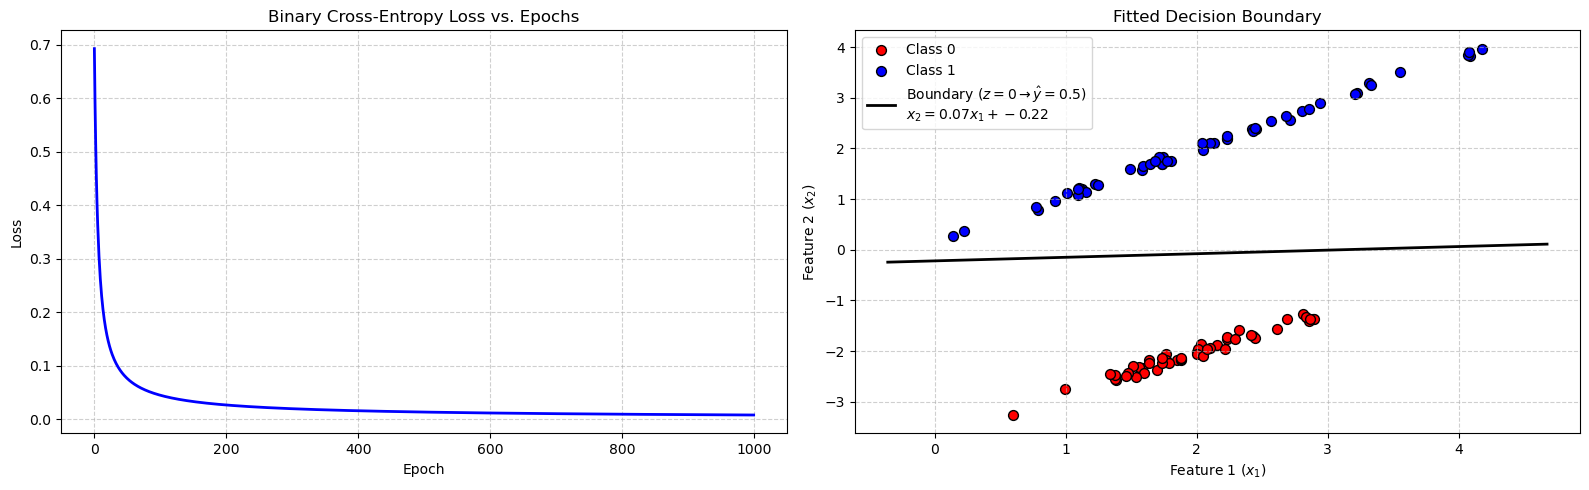

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification


# 1. Custom Logistic Regression Class
class LogisticRegressionScratch:

    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Clip z to prevent numerical overflow in exp(-z)
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred):
        n = len(y_true)
        # Add epsilon to prevent log(0) which results in undefined (-inf)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)

        # Binary Cross-Entropy Loss formula:
        # L = -(1/n) * sum[ y * log(y_hat) + (1 - y) * log(1 - y_hat) ]
        loss = -(1 / n) * np.sum(
            y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
        )
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Prepend bias feature (x0 = 1) -> shape: (n_samples, n_features + 1)
        X_bias = np.insert(X, 0, 1, axis=1)

        # Initialize weights: [w0 (bias), w1, w2, ...]
        self.weights = np.zeros(n_features + 1)

        for epoch in range(self.epochs):
            # 1. Linear combination: z = Xw
            z = np.dot(X_bias, self.weights)

            # 2. Probability prediction via sigmoid
            y_hat = self._sigmoid(z)

            # 3. Calculate and record cross-entropy loss
            loss = self._compute_loss(y, y_hat)
            self.loss_history.append(loss)

            # 4. Compute gradient of loss with respect to weights: (1/n) * X^T * (y_hat - y)
            gradient = (1 / n_samples) * np.dot(X_bias.T, (y_hat - y))

            # 5. Gradient Descent weight update
            self.weights -= self.lr * gradient

    def predict_proba(self, X):
        X_bias = np.insert(X, 0, 1, axis=1)
        return self._sigmoid(np.dot(X_bias, self.weights))

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities >= 0.5).astype(int)


# 2. Generate Linearly Separable Dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
    class_sep=2.0,
)

# 3. Train the Model
model = LogisticRegressionScratch(lr=0.1, epochs=1000)
model.fit(X, y)

w0, w1, w2 = model.weights
print(f"Final Weights: Bias (w0) = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}")
print(f"Final Loss: {model.loss_history[-1]:.4f}")

# Compute accuracy
y_pred = model.predict(X)
accuracy = np.mean(y_pred == y) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

# 4. Visualizations (Loss Curve & Decision Boundary)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Binary Cross-Entropy Loss over Epochs
ax1.plot(model.loss_history, color="blue", linewidth=2)
ax1.set_title("Binary Cross-Entropy Loss vs. Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot 2: Decision Boundary (w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w1/w2)*x1 - (w0/w2))
m = -(w1 / w2)
c = -(w0 / w2)
x_vals = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
y_vals = m * x_vals + c

ax2.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="red",
    edgecolors="k",
    s=50,
    label="Class 0",
)
ax2.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="blue",
    edgecolors="k",
    s=50,
    label="Class 1",
)
ax2.plot(
    x_vals,
    y_vals,
    color="black",
    linewidth=2,
    label=rf"Boundary ($z=0 \rightarrow \hat{{y}}=0.5$)"
    + f"\n$x_2 = {m:.2f}x_1 + {c:.2f}$",
)

ax2.set_title("Fitted Decision Boundary")
ax2.set_xlabel(r"Feature 1 ($x_1$)")
ax2.set_ylabel(r"Feature 2 ($x_2$)")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

=== 5-Fold Cross-Validation Accuracy ===
Logistic Regression : Mean = 0.9695 (± 0.0095)
KNN                 : Mean = 0.9624 (± 0.0157)


C:\Users\SIC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\SIC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\SIC\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SIC\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\SIC\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(execu

Decision Tree       : Mean = 0.9297 (± 0.0284)

=== Best Hyperparameters & Test Set Evaluation ===

Model: Logistic Regression
Best Params: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


Model: KNN
Best Params: {'clf__n_neighbors': 11, 'clf__weights': 'distance'}
              precision    recall  f1-score   support

   malignant       1.00      0.92      0.96        53
      benign       0.96      1.00      0.98        90

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143


Model: Decision Tree
Best Params: {'clf__criterion': 'entropy', 'clf__max_depth': N

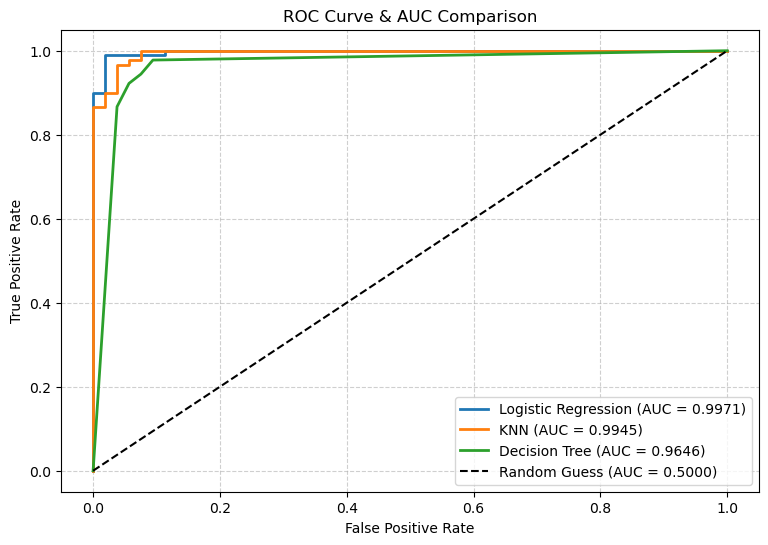

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Setup Models with Pipelines (Scaling where needed)
models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    ),
    "KNN": Pipeline(
        [("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]
    ),
    "Decision Tree": Pipeline(
        [("clf", DecisionTreeClassifier(random_state=42))]
    ),
}

# 3. 5-Fold Cross-Validation Comparison
print("=== 5-Fold Cross-Validation Accuracy ===")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:20s}: Mean = {scores.mean():.4f} (± {scores.std():.4f})")

# 4. Hyperparameter Tuning using GridSearchCV
param_grids = {
    "Logistic Regression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 9, 11],
        "clf__weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "clf__max_depth": [3, 5, 7, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__criterion": ["gini", "entropy"],
    },
}

best_models = {}
plt.figure(figsize=(9, 6))

print("\n=== Best Hyperparameters & Test Set Evaluation ===")
for name, pipe in models.items():
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_

    print(f"\nModel: {name}")
    print(f"Best Params: {grid.best_params_}")

    # Predictions
    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]

    # Precision, Recall, F1-Score
    print(classification_report(y_test, y_pred, target_names=data.target_names))

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.4f})")

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve & AUC Comparison")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

=== Loan Approval System: Model Comparison ===

--- Logistic Regression ---
ROC-AUC Score: 0.9679
              precision    recall  f1-score   support

      Denied       0.96      0.92      0.94       111
    Approved       0.80      0.90      0.84        39

    accuracy                           0.91       150
   macro avg       0.88      0.91      0.89       150
weighted avg       0.92      0.91      0.91       150


--- Decision Tree ---
ROC-AUC Score: 0.9571
              precision    recall  f1-score   support

      Denied       0.95      0.91      0.93       111
    Approved       0.77      0.87      0.82        39

    accuracy                           0.90       150
   macro avg       0.86      0.89      0.88       150
weighted avg       0.91      0.90      0.90       150


--- Random Forest ---
ROC-AUC Score: 0.9675
              precision    recall  f1-score   support

      Denied       0.96      0.93      0.94       111
    Approved       0.81      0.90      0.85      

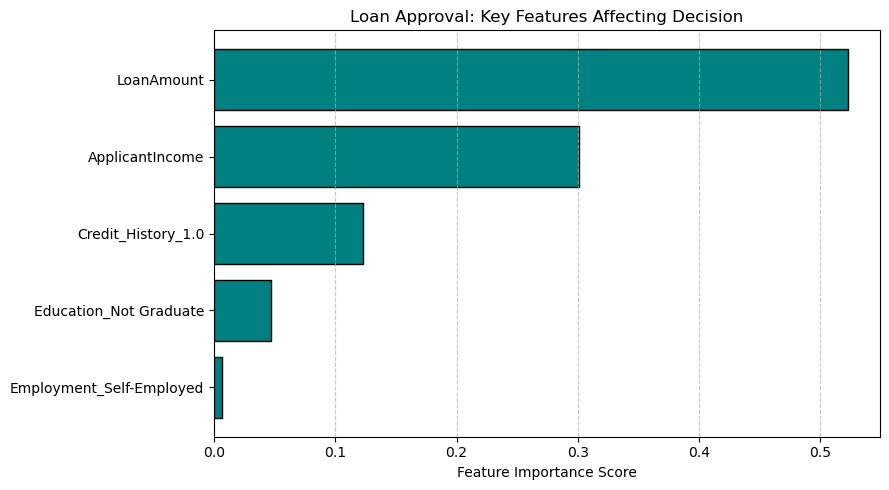

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 1. Create a representative Loan Approval Dataset
np.random.seed(42)
n_samples = 600

applicant_income = np.random.exponential(scale=5000, size=n_samples) + 1500
loan_amount = (applicant_income * 0.3) + np.random.normal(
    loc=500, scale=200, size=n_samples
)
education = np.random.choice(["Graduate", "Not Graduate"], size=n_samples, p=[0.75, 0.25])
employment = np.random.choice(["Salaried", "Self-Employed"], size=n_samples, p=[0.8, 0.2])
credit_history = np.random.choice([1.0, 0.0, np.nan], size=n_samples, p=[0.75, 0.2, 0.05])

# Loan approval logic (Credit history has the strongest pull)
z = (
    0.0003 * applicant_income
    - 0.002 * loan_amount
    + 3.5 * np.nan_to_num(credit_history, nan=0.5)
    + (education == "Graduate") * 0.5
    - 1.8
)
prob = 1 / (1 + np.exp(-z))
loan_status = (prob >= 0.5).astype(int)

df = pd.DataFrame(
    {
        "ApplicantIncome": applicant_income,
        "LoanAmount": loan_amount,
        "Education": education,
        "Employment": employment,
        "Credit_History": credit_history,
        "Loan_Status": loan_status,
    }
)

# 2. Data Preprocessing Pipeline
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

num_features = ["ApplicantIncome", "LoanAmount"]
cat_features = ["Education", "Employment", "Credit_History"]

num_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Model Comparison
candidates = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

print("=== Loan Approval System: Model Comparison ===")
for name, clf in candidates.items():
    pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("classifier", clf)]
    )
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    print(f"\n--- {name} ---")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Denied", "Approved"]))

# 4. Feature Importance Explanation (Using Random Forest)
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(n_estimators=100, random_state=42),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)

# Extract transformed feature names
encoded_cat_names = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
)
all_features = np.concatenate([num_features, encoded_cat_names])
importances = rf_pipeline.named_steps["classifier"].feature_importances_

# Plot Top Factors
feat_df = pd.DataFrame({"Feature": all_features, "Importance": importances}).sort_values(
    by="Importance", ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="teal", edgecolor="k")
plt.xlabel("Feature Importance Score")
plt.title("Loan Approval: Key Features Affecting Decision")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier, export_text

# =========================================================
# 1. Import Built-in Scikit-Learn Dataset
# =========================================================
data = load_breast_cancer()
X_raw = data.data
y = data.target
feature_names = [f.replace(" ", "_") for f in data.feature_names]

# Select the top 5 most informative features for clarity and manageable tree depth
selected_indices = [0, 2, 3, 20, 23]  # mean radius, perimeter, area, worst radius, worst area
selected_features = [feature_names[i] for i in selected_indices]
X_subset = X_raw[:, selected_indices]

# Split into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_subset, y, test_size=0.25, random_state=42, stratify=y
)

# Discretize continuous features into 3 bins ('Low', 'Med', 'High') for ID3 / C4.5
discretizer = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")
X_train_binned = discretizer.fit_transform(X_train_raw).astype(int)
X_test_binned = discretizer.transform(X_test_raw).astype(int)

# Create Pandas DataFrames
train_df = pd.DataFrame(X_train_binned, columns=selected_features)
train_df["target"] = y_train

test_df = pd.DataFrame(X_test_binned, columns=selected_features)
test_df["target"] = y_test

# =========================================================
# 2. Information Theory Metrics (Entropy, IG, Gain Ratio)
# =========================================================
def compute_entropy(labels):
    probs = labels.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

def compute_information_gain(df, feature, target_col="target"):
    base_entropy = compute_entropy(df[target_col])
    values, counts = np.unique(df[feature], return_counts=True)
    weighted_entropy = sum(
        (counts[i] / len(df)) * compute_entropy(df[df[feature] == values[i]][target_col])
        for i in range(len(values))
    )
    return base_entropy - weighted_entropy

def compute_gain_ratio(df, feature, target_col="target"):
    ig = compute_information_gain(df, feature, target_col)
    probs = df[feature].value_counts(normalize=True)
    split_info = -np.sum(probs * np.log2(probs + 1e-9))
    if split_info == 0:
        return 0
    return ig / split_info

# =========================================================
# 3. Decision Tree Implementation (ID3 & C4.5)
# =========================================================
def build_tree(df, features, target_col="target", criterion="id3", max_depth=3, depth=0):
    unique_classes = df[target_col].unique()
    
    # Base cases
    if len(unique_classes) == 1:
        return unique_classes[0]
    if len(features) == 0 or depth >= max_depth:
        return df[target_col].mode()[0]
    
    # Metric selection
    if criterion == "id3":
        scores = [compute_information_gain(df, feat, target_col) for feat in features]
    elif criterion == "c4.5":
        scores = [compute_gain_ratio(df, feat, target_col) for feat in features]
        
    best_idx = int(np.argmax(scores))
    best_feat = features[best_idx]
    
    tree = {best_feat: {}}
    remaining_features = [f for f in features if f != best_feat]
    
    for val in [0, 1, 2]:  # 3 bins: 0 (Low), 1 (Med), 2 (High)
        sub_df = df[df[best_feat] == val]
        if len(sub_df) == 0:
            tree[best_feat][val] = df[target_col].mode()[0]
        else:
            tree[best_feat][val] = build_tree(
                sub_df, remaining_features, target_col, criterion, max_depth, depth + 1
            )
            
    return tree

def predict_single(tree, sample, default_label=1):
    if not isinstance(tree, dict):
        return tree
    feature = next(iter(tree))
    val = sample[feature]
    if val in tree[feature]:
        return predict_single(tree[feature][val], sample, default_label)
    return default_label

def predict_batch(tree, df):
    return [predict_single(tree, row) for _, row in df.iterrows()]

# Train custom ID3 and C4.5 models
id3_tree = build_tree(train_df, selected_features, criterion="id3", max_depth=3)
c45_tree = build_tree(train_df, selected_features, criterion="c4.5", max_depth=3)

# =========================================================
# 4. CART Implementation (Standard Scikit-Learn Model)
# =========================================================
cart_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
cart_model.fit(X_train_raw, y_train)

# =========================================================
# 5. Model Evaluation and Comparison
# =========================================================
# Predictions
preds_id3 = predict_batch(id3_tree, test_df)
preds_c45 = predict_batch(c45_tree, test_df)
preds_cart = cart_model.predict(X_test_raw)

# Metrics Compilation
models_dict = {
    "ID3 (Entropy / Information Gain)": preds_id3,
    "C4.5 (Normalized Gain Ratio)": preds_c45,
    "CART (Gini Impurity, Binary)": preds_cart,
}

comparison_records = []
for name, preds in models_dict.items():
    comparison_records.append({
        "Algorithm": name,
        "Accuracy": f"{accuracy_score(y_test, preds) * 100:.2f}%",
        "Precision": f"{precision_score(y_test, preds):.4f}",
        "Recall": f"{recall_score(y_test, preds):.4f}",
        "F1-Score": f"{f1_score(y_test, preds):.4f}",
    })

comparison_df = pd.DataFrame(comparison_records)

print("=" * 75)
print("ALGORITHM PERFORMANCE COMPARISON (Breast Cancer Wisconsin Dataset)")
print("=" * 75)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 75)
print("CART DECISION TREE RULES (Scikit-Learn)")
print("=" * 75)
print(export_text(cart_model, feature_names=selected_features))

ALGORITHM PERFORMANCE COMPARISON (Breast Cancer Wisconsin Dataset)
                       Algorithm Accuracy Precision Recall F1-Score
ID3 (Entropy / Information Gain)   91.61%    0.9149 0.9556   0.9348
    C4.5 (Normalized Gain Ratio)   91.61%    0.9149 0.9556   0.9348
    CART (Gini Impurity, Binary)   91.61%    0.9062 0.9667   0.9355

CART DECISION TREE RULES (Scikit-Learn)
|--- worst_radius <= 16.80
|   |--- worst_area <= 711.30
|   |   |--- mean_area <= 665.70
|   |   |   |--- class: 1
|   |   |--- mean_area >  665.70
|   |   |   |--- class: 0
|   |--- worst_area >  711.30
|   |   |--- mean_area <= 567.65
|   |   |   |--- class: 0
|   |   |--- mean_area >  567.65
|   |   |   |--- class: 1
|--- worst_radius >  16.80
|   |--- worst_area <= 936.20
|   |   |--- mean_area <= 668.50
|   |   |   |--- class: 0
|   |   |--- mean_area >  668.50
|   |   |   |--- class: 1
|   |--- worst_area >  936.20
|   |   |--- worst_area <= 1216.00
|   |   |   |--- class: 0
|   |   |--- worst_area >  1216

In [32]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

# 1. Load Wine Dataset (3 Classes, 13 Continuous Features)
data = load_wine()
X_raw = data.data
y = data.target
feature_names = [f.replace(" ", "_") for f in data.feature_names]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)

# 2. Binning with differing cardinalities to expose C4.5's Split Info penalty
# ID3 naturally favors features with more splits; C4.5 penalizes them via SplitInfo
n_bins = 4
discretizer = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="uniform")
X_train_binned = discretizer.fit_transform(X_train_raw).astype(int)
X_test_binned = discretizer.transform(X_test_raw).astype(int)

train_df = pd.DataFrame(X_train_binned, columns=feature_names)
train_df["target"] = y_train

test_df = pd.DataFrame(X_test_binned, columns=feature_names)
test_df["target"] = y_test

# 3. Information Theory Functions
def compute_entropy(labels):
    probs = labels.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

def compute_information_gain(df, feature, target_col="target"):
    base_entropy = compute_entropy(df[target_col])
    values, counts = np.unique(df[feature], return_counts=True)
    weighted_entropy = sum(
        (counts[i] / len(df)) * compute_entropy(df[df[feature] == values[i]][target_col])
        for i in range(len(values))
    )
    return base_entropy - weighted_entropy

def compute_gain_ratio(df, feature, target_col="target"):
    ig = compute_information_gain(df, feature, target_col)
    probs = df[feature].value_counts(normalize=True)
    split_info = -np.sum(probs * np.log2(probs + 1e-9))
    if split_info == 0:
        return 0
    return ig / split_info

# 4. Tree Construction (ID3 vs C4.5)
def build_tree(df, features, target_col="target", criterion="id3", max_depth=3, depth=0):
    unique_classes = df[target_col].unique()
    if len(unique_classes) == 1:
        return unique_classes[0]
    if len(features) == 0 or depth >= max_depth:
        return df[target_col].mode()[0]

    if criterion == "id3":
        scores = [compute_information_gain(df, feat, target_col) for feat in features]
    elif criterion == "c4.5":
        scores = [compute_gain_ratio(df, feat, target_col) for feat in features]

    best_idx = int(np.argmax(scores))
    best_feat = features[best_idx]

    tree = {best_feat: {}}
    remaining_features = [f for f in features if f != best_feat]

    for val in range(n_bins):
        sub_df = df[df[best_feat] == val]
        if len(sub_df) == 0:
            tree[best_feat][val] = df[target_col].mode()[0]
        else:
            tree[best_feat][val] = build_tree(
                sub_df, remaining_features, target_col, criterion, max_depth, depth + 1
            )
    return tree

def predict_single(tree, sample, default_label=1):
    if not isinstance(tree, dict):
        return tree
    feature = next(iter(tree))
    val = sample[feature]
    if val in tree[feature]:
        return predict_single(tree[feature][val], sample, default_label)
    return default_label

def predict_batch(tree, df):
    return [predict_single(tree, row) for _, row in df.iterrows()]

# Train ID3 and C4.5
id3_tree = build_tree(train_df, feature_names, criterion="id3", max_depth=3)
c45_tree = build_tree(train_df, feature_names, criterion="c4.5", max_depth=3)

# 5. Train CART on Continuous Data Directly
cart_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
cart_model.fit(X_train_raw, y_train)

# 6. Evaluate and Compare
preds_id3 = predict_batch(id3_tree, test_df)
preds_c45 = predict_batch(c45_tree, test_df)
preds_cart = cart_model.predict(X_test_raw)

models = {
    "ID3 (Information Gain)": preds_id3,
    "C4.5 (Gain Ratio)": preds_c45,
    "CART (Continuous Gini Binary)": preds_cart,
}

results = []
for name, preds in models.items():
    results.append({
        "Algorithm": name,
        "Accuracy": f"{accuracy_score(y_test, preds) * 100:.2f}%",
        "Precision (Macro)": f"{precision_score(y_test, preds, average='macro'):.4f}",
        "Recall (Macro)": f"{recall_score(y_test, preds, average='macro'):.4f}",
        "F1-Score (Macro)": f"{f1_score(y_test, preds, average='macro'):.4f}",
    })

print("=" * 80)
print("ALGORITHM PERFORMANCE COMPARISON (Wine Recognition Dataset)")
print("=" * 80)
print(pd.DataFrame(results).to_string(index=False))

ALGORITHM PERFORMANCE COMPARISON (Wine Recognition Dataset)
                    Algorithm Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro)
       ID3 (Information Gain)   88.89%            0.8894         0.8894           0.8894
            C4.5 (Gain Ratio)   90.74%            0.9072         0.9180           0.9094
CART (Continuous Gini Binary)   96.30%            0.9710         0.9593           0.9638


In [34]:
# Function to recursively format and print multi-way dictionary trees (ID3 and C4.5)
def print_dict_tree(tree, indent=""):
    if not isinstance(tree, dict):
        print(f"{indent}└── Class {tree}")
        return
    feature = next(iter(tree))
    items = list(tree[feature].items())
    for i, (val, subtree) in enumerate(items):
        connector = "├── " if i < len(items) - 1 else "└── "
        print(f"{indent}{connector}{feature} == Bin {val}")
        next_indent = indent + ("│   " if i < len(items) - 1 else "    ")
        print_dict_tree(subtree, next_indent)


print("=" * 60)
print("1. ID3 TREE STRUCTURE (Multi-way, Information Gain)")
print("=" * 60)
print_dict_tree(id3_tree)

print("\n" + "=" * 60)
print("2. C4.5 TREE STRUCTURE (Multi-way, Gain Ratio)")
print("=" * 60)
print_dict_tree(c45_tree)

print("\n" + "=" * 60)
print("3. CART TREE STRUCTURE (Strictly Binary, Continuous Gini)")
print("=" * 60)
print(export_text(cart_model, feature_names=feature_names))

1. ID3 TREE STRUCTURE (Multi-way, Information Gain)
├── flavanoids == Bin 0
│   ├── nonflavanoid_phenols == Bin 0
│   │   └── Class 1
│   ├── nonflavanoid_phenols == Bin 1
│   │   ├── alcohol == Bin 0
│   │   │   └── Class 1
│   │   ├── alcohol == Bin 1
│   │   │   └── Class 1
│   │   ├── alcohol == Bin 2
│   │   │   └── Class 2
│   │   └── alcohol == Bin 3
│   │       └── Class 1
│   ├── nonflavanoid_phenols == Bin 2
│   │   └── Class 2
│   └── nonflavanoid_phenols == Bin 3
│       └── Class 2
├── flavanoids == Bin 1
│   ├── hue == Bin 0
│   │   └── Class 2
│   ├── hue == Bin 1
│   │   └── Class 1
│   ├── hue == Bin 2
│   │   └── Class 1
│   └── hue == Bin 3
│       └── Class 1
├── flavanoids == Bin 2
│   ├── alcohol == Bin 0
│   │   └── Class 1
│   ├── alcohol == Bin 1
│   │   └── Class 1
│   ├── alcohol == Bin 2
│   │   ├── proline == Bin 0
│   │   │   └── Class 1
│   │   ├── proline == Bin 1
│   │   │   └── Class 0
│   │   ├── proline == Bin 2
│   │   │   └── Class 0
│   │   └── pr